# 📚 Data Science — Chatbot Edukatif IPA SD
**Coding Camp 2026 powered by DBS Foundation**  
**ID Tim: CC26-PSU312** | Tema: Accessible & Adaptive Learning

---

## 🎯 Tujuan Notebook
Notebook ini mencakup seluruh pipeline Data Science mulai dari:
1. Problem Definition & Business Questions
2. Data Gathering
3. Data Assessing (Pemeriksaan Kualitas Data)
4. Data Wrangling / Cleaning
5. Exploratory Data Analysis (EDA)
6. Explanatory Analysis & Visualisasi
7. Feature Engineering
8. Data Dictionary
9. Export Data Bersih

---
## 1️⃣ Problem Definition

### Latar Belakang
Banyak siswa SD mengalami kesulitan memahami konsep IPA yang bersifat abstrak.
Proyek ini mengembangkan **chatbot edukatif** berbasis kuis adaptif.
Peran Data Science adalah memastikan dataset Q&A IPA berkualitas tinggi dan siap digunakan sebagai bahan training model AI.

### Business Questions
1. Topik IPA apa yang paling banyak dibahas dalam dataset?
2. Bagaimana distribusi panjang soal dan jawaban?
3. Subtopik mana yang memiliki jumlah soal terbanyak?
4. Apakah ada ketidakkonsistenan penulisan topik (duplikat semantik)?
5. Bagaimana distribusi kompleksitas soal berdasarkan panjang teks?

---
## 2️⃣ Import Library

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import warnings
import os
import re

warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
PALETTE = sns.color_palette('Set2')
sns.set_palette(PALETTE)

print('✅ Library berhasil diimport')

✅ Library berhasil diimport


---
## 3️⃣ Data Gathering — Memuat Dataset

In [25]:
# Load dataset
DATA_PATH = 'datasoal.csv'
df_raw = pd.read_csv(DATA_PATH)

print(f'✅ Dataset berhasil dimuat')
print(f'📊 Jumlah baris   : {df_raw.shape[0]:,}')
print(f'📋 Jumlah kolom   : {df_raw.shape[1]}')
print(f'\n📝 Kolom: {df_raw.columns.tolist()}')
df_raw.head(3)

✅ Dataset berhasil dimuat
📊 Jumlah baris   : 1,327
📋 Jumlah kolom   : 8

📝 Kolom: ['no', 'topik', 'subtopik', 'soal', 'jawaban', 'contoh', 'konteks', 'link sumber buku']


,no,topik,subtopik,soal,jawaban,contoh,konteks,link sumber buku
0,1,alat tubuh manusia dan hewan,sistem pernapasan manusia,sebutkan alat pernapasan pada manusia!,rongga hidung berfungsi sebagai pintu masuk ud...,"udara masuk melalui hidung, lalu melewati trak...",manusia bernapas dengan bantuan beberapa organ...,https://www.omahbse.com/ktsp/file/sd-5_ipa_002/
1,2,alat tubuh manusia dan hewan,sistem pernapasan manusia,apa saja alat pernapasan pada manusia?,rongga hidung berfungsi sebagai pintu masuk ud...,"udara masuk melalui hidung, lalu melewati trak...",manusia bernapas dengan bantuan beberapa organ...,https://www.omahbse.com/ktsp/file/sd-5_ipa_002/
2,3,alat tubuh manusia dan hewan,sistem pernapasan manusia,tuliskan alat pernapasan manusia!,rongga hidung berfungsi sebagai pintu masuk ud...,"udara masuk melalui hidung, lalu melewati trak...",manusia bernapas dengan bantuan beberapa organ...,https://www.omahbse.com/ktsp/file/sd-5_ipa_002/


In [26]:
# Sumber data
print('🔗 Sumber Data Unik:')
for url in df_raw['link sumber buku'].unique():
    print(f'  → {url}')

🔗 Sumber Data Unik:
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_002/
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_013/
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_012/
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_007/view/
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_001/


---
## 4️⃣ Data Assessing — Pemeriksaan Kualitas Data

In [27]:
print('=' * 55)
print('📋 INFO DATASET')
print('=' * 55)
df_raw.info()

📋 INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1327 entries, 0 to 1326
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   no                1327 non-null   int64 
 1   topik             1327 non-null   object
 2   subtopik          1327 non-null   object
 3   soal              1327 non-null   object
 4   jawaban           1327 non-null   object
 5   contoh            1327 non-null   object
 6   konteks           1327 non-null   object
 7   link sumber buku  1327 non-null   object
dtypes: int64(1), object(7)
memory usage: 83.1+ KB


In [28]:
print('=' * 55)
print('🔍 PEMERIKSAAN MISSING VALUES')
print('=' * 55)
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
print(missing_df)

if missing.sum() == 0:
    print('\n✅ Tidak ada missing values!')
else:
    print(f'\n⚠️  Total missing: {missing.sum()}')

🔍 PEMERIKSAAN MISSING VALUES
                  Jumlah Missing  Persentase (%)
no                             0             0.0
topik                          0             0.0
subtopik                       0             0.0
soal                           0             0.0
jawaban                        0             0.0
contoh                         0             0.0
konteks                        0             0.0
link sumber buku               0             0.0

✅ Tidak ada missing values!


In [29]:
# Fungsi tambahan: normalisasi lowercase untuk kolom teks

def to_lowercase_columns(dataframe: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Ubah isi kolom-kolom teks menjadi lowercase dan trim spasi."""
    for col in columns:
        if col in dataframe.columns:
            dataframe[col] = dataframe[col].astype(str).str.lower().str.strip()
    return dataframe

lower_cols = ['topik', 'subtopik', 'soal', 'jawaban', 'contoh', 'konteks']
df = to_lowercase_columns(df, lower_cols)

print('✅ Normalisasi lowercase selesai untuk kolom teks.')
print(f'Kolom diproses: {lower_cols}')

✅ Normalisasi lowercase selesai untuk kolom teks.
Kolom diproses: ['topik', 'subtopik', 'soal', 'jawaban', 'contoh', 'konteks']


In [30]:
print('=' * 55)
print('🔁 PEMERIKSAAN DUPLIKASI')
print('=' * 55)
dup_rows = df_raw.duplicated().sum()
dup_soal = df_raw['soal'].duplicated().sum()

print(f'Baris duplikat penuh    : {dup_rows}')
print(f'Soal duplikat (teks sama): {dup_soal}')

if dup_soal > 0:
    print(f'\n⚠️  Contoh soal duplikat:')
    dup_examples = df_raw[df_raw['soal'].duplicated(keep=False)].sort_values('soal')
    print(dup_examples[['no','topik','soal']].head(4).to_string(index=False))

🔁 PEMERIKSAAN DUPLIKASI
Baris duplikat penuh    : 0
Soal duplikat (teks sama): 153

⚠️  Contoh soal duplikat:
  no                   topik                                        soal
1271 Bumi dan Peristiwa Alam Apa alasan air di bumi tidak habis-habis...
1322 Bumi dan Peristiwa Alam Apa alasan air di bumi tidak habis-habis...
1319 Bumi dan Peristiwa Alam Apa alasan air di bumi tidak habis-habis...
1265 Bumi dan Peristiwa Alam Apa alasan air di bumi tidak habis-habis...


In [31]:
print('=' * 55)
print('📝 PEMERIKSAAN KONSISTENSI TOPIK')
print('=' * 55)
print(f'Jumlah nilai unik topik  : {df_raw["topik"].nunique()}')
print(f'\nDaftar topik unik:')
for i, t in enumerate(sorted(df_raw['topik'].unique()), 1):
    print(f'  {i:2d}. "{t}"')

📝 PEMERIKSAAN KONSISTENSI TOPIK
Jumlah nilai unik topik  : 29

Daftar topik unik:
   1. "Air"
   2. "Bahan Penyusun Benda dan Sifatnya"
   3. "Benda dan Sifatnya"
   4. "Bumi dan Peristiwa Alam"
   5. "Merancang Karya atau Model dengan Menerapkan Sifat Cahaya"
   6. "Organ Tubuh Manusia dan Hewan"
   7. "Pembuatan Makanan pada Tumbuhan Hijau"
   8. "Pengaruh Gaya terhadap Bentuk dan Gerak Suatu Benda"
   9. "Penyesuaian Diri Makhluk Hidup dengan Lingkungannya"
  10. "Peristiwa Alam"
  11. "Perubahan Sifat Benda"
  12. "Pesawat Sederhana"
  13. "Sifat-sifat Cahaya"
  14. "Struktur Bumi"
  15. "adaptasi makhluk hidup"
  16. "air"
  17. "alat tubuh manusia dan hewan"
  18. "batuan dan proses pembentukan tanah"
  19. "benda dan sifatnya"
  20. "bumi dan peristiwa alam"
  21. "cahaya dan sifat-sifatnya"
  22. "darah"
  23. "gaya, gerak, dan energi"
  24. "perubahan benda"
  25. "pesawat sederhana"
  26. "sistem pencernaan"
  27. "sistem pernapasan"
  28. "sumber daya alam dan kegiatan manus

In [32]:
# Deteksi inkonsistensi kapitalisasi topik
print('⚠️  INKONSISTENSI KAPITALISASI TOPIK (Duplikat Semantik):')
df_raw['topik_lower'] = df_raw['topik'].str.lower().str.strip()
dup_topics = df_raw.groupby('topik_lower')['topik'].unique()
inconsistent = dup_topics[dup_topics.apply(len) > 1]
for key, vals in inconsistent.items():
    print(f'  → "{key}" → ditemukan sebagai: {list(vals)}')

print(f'\n📊 Total inkonsistensi topik: {len(inconsistent)}')
df_raw.drop(columns=['topik_lower'], inplace=True)

⚠️  INKONSISTENSI KAPITALISASI TOPIK (Duplikat Semantik):
  → "air" → ditemukan sebagai: ['air', 'Air']
  → "benda dan sifatnya" → ditemukan sebagai: ['benda dan sifatnya', 'Benda dan Sifatnya']
  → "bumi dan peristiwa alam" → ditemukan sebagai: ['bumi dan peristiwa alam', 'Bumi dan Peristiwa Alam']
  → "pesawat sederhana" → ditemukan sebagai: ['pesawat sederhana', 'Pesawat Sederhana']

📊 Total inkonsistensi topik: 4


---
## 5️⃣ Data Wrangling / Cleaning

In [33]:
df = df_raw.copy()
issues_fixed = []

# --- 1. Normalisasi teks kolom topik & subtopik ---
before_unique = df['topik'].nunique()
df['topik'] = df['topik'].str.lower().str.strip()
df['subtopik'] = df['subtopik'].str.lower().str.strip()
after_unique = df['topik'].nunique()
issues_fixed.append(f'Normalisasi topik: {before_unique} → {after_unique} nilai unik')

# --- 2. Trim whitespace pada semua kolom teks ---
text_cols = ['soal', 'jawaban', 'contoh', 'konteks']
for col in text_cols:
    df[col] = df[col].str.strip()
issues_fixed.append('Trim whitespace pada kolom teks (soal, jawaban, contoh, konteks)')

# --- 3. Hapus duplikasi soal ---
before_len = len(df)
df = df.drop_duplicates(subset='soal', keep='first').reset_index(drop=True)
after_len = len(df)
issues_fixed.append(f'Hapus soal duplikat: {before_len - after_len} baris dihapus ({after_len} tersisa)')

# --- 4. Reset nomor urut ---
df['no'] = range(1, len(df) + 1)
issues_fixed.append('Reset kolom no (nomor urut)')

# --- 5. Rename kolom ---
df.rename(columns={'link sumber buku': 'link_sumber'}, inplace=True)
issues_fixed.append('Rename "link sumber buku" → "link_sumber"')

print('✅ HASIL DATA CLEANING:')
for i, fix in enumerate(issues_fixed, 1):
    print(f'  {i}. {fix}')

print(f'\n📊 Ukuran dataset: {df_raw.shape} → {df.shape}')

✅ HASIL DATA CLEANING:
  1. Normalisasi topik: 29 → 25 nilai unik
  2. Trim whitespace pada kolom teks (soal, jawaban, contoh, konteks)
  3. Hapus soal duplikat: 153 baris dihapus (1174 tersisa)
  4. Reset kolom no (nomor urut)
  5. Rename "link sumber buku" → "link_sumber"

📊 Ukuran dataset: (1327, 8) → (1174, 8)


In [34]:
# Verifikasi hasil cleaning
print('🔍 Verifikasi Pasca Cleaning:')
print(f'  Missing values  : {df.isnull().sum().sum()}')
print(f'  Duplikat soal   : {df["soal"].duplicated().sum()}')
print(f'  Topik unik      : {df["topik"].nunique()}')
df.head(3)

🔍 Verifikasi Pasca Cleaning:
  Missing values  : 0
  Duplikat soal   : 0
  Topik unik      : 25


,no,topik,subtopik,soal,jawaban,contoh,konteks,link_sumber
0,1,alat tubuh manusia dan hewan,sistem pernapasan manusia,sebutkan alat pernapasan pada manusia!,rongga hidung berfungsi sebagai pintu masuk ud...,"udara masuk melalui hidung, lalu melewati trak...",manusia bernapas dengan bantuan beberapa organ...,https://www.omahbse.com/ktsp/file/sd-5_ipa_002/
1,2,alat tubuh manusia dan hewan,sistem pernapasan manusia,apa saja alat pernapasan pada manusia?,rongga hidung berfungsi sebagai pintu masuk ud...,"udara masuk melalui hidung, lalu melewati trak...",manusia bernapas dengan bantuan beberapa organ...,https://www.omahbse.com/ktsp/file/sd-5_ipa_002/
2,3,alat tubuh manusia dan hewan,sistem pernapasan manusia,tuliskan alat pernapasan manusia!,rongga hidung berfungsi sebagai pintu masuk ud...,"udara masuk melalui hidung, lalu melewati trak...",manusia bernapas dengan bantuan beberapa organ...,https://www.omahbse.com/ktsp/file/sd-5_ipa_002/


---
## 6️⃣ Feature Engineering

In [35]:
# Fitur panjang teks
df['panjang_soal']    = df['soal'].str.len()
df['panjang_jawaban'] = df['jawaban'].str.len()
df['panjang_konteks'] = df['konteks'].str.len()

# Fitur jumlah kata
df['kata_soal']    = df['soal'].str.split().str.len()
df['kata_jawaban'] = df['jawaban'].str.split().str.len()

# Fitur jenis pertanyaan
def jenis_pertanyaan(soal):
    soal_lower = soal.lower()
    if soal_lower.startswith('apa'):
        return 'apa'
    elif soal_lower.startswith('bagaimana'):
        return 'bagaimana'
    elif soal_lower.startswith('mengapa'):
        return 'mengapa'
    elif soal_lower.startswith('sebutkan'):
        return 'sebutkan'
    elif soal_lower.startswith('jelaskan'):
        return 'jelaskan'
    elif soal_lower.startswith('berapa'):
        return 'berapa'
    else:
        return 'lainnya'

df['jenis_pertanyaan'] = df['soal'].apply(jenis_pertanyaan)

# Tingkat kompleksitas soal berdasarkan jumlah kata
def tingkat_kompleksitas(n_kata):
    if n_kata <= 6:
        return 'Mudah'
    elif n_kata <= 10:
        return 'Sedang'
    else:
        return 'Kompleks'

df['kompleksitas'] = df['kata_soal'].apply(tingkat_kompleksitas)

print('✅ Feature engineering selesai. Fitur baru:')
new_feats = ['panjang_soal','panjang_jawaban','panjang_konteks',
             'kata_soal','kata_jawaban','jenis_pertanyaan','kompleksitas']
for f in new_feats:
    print(f'  + {f}')
df[new_feats].head(4)

✅ Feature engineering selesai. Fitur baru:
  + panjang_soal
  + panjang_jawaban
  + panjang_konteks
  + kata_soal
  + kata_jawaban
  + jenis_pertanyaan
  + kompleksitas


,panjang_soal,panjang_jawaban,panjang_konteks,kata_soal,kata_jawaban,jenis_pertanyaan,kompleksitas
0,38,139,69,5,19,sebutkan,Mudah
1,38,139,69,6,19,apa,Mudah
2,33,139,69,4,19,lainnya,Mudah
3,39,107,92,6,14,apa,Mudah


---
## 7️⃣ Exploratory Data Analysis (EDA)

In [36]:
print('=' * 55)
print('📊 STATISTIK DESKRIPTIF — FITUR NUMERIK')
print('=' * 55)
df[['panjang_soal','panjang_jawaban','kata_soal','kata_jawaban']].describe().round(2)

📊 STATISTIK DESKRIPTIF — FITUR NUMERIK


,panjang_soal,panjang_jawaban,kata_soal,kata_jawaban
count,1174.00,1174.00,1174.00,1174.00
mean,50.95,97.07,7.24,13.79
std,17.38,71.45,2.51,10.22
min,14.00,3.00,2.00,1.00
25%,38.00,48.00,5.00,7.00
50%,48.00,61.00,7.00,8.00
75%,63.00,165.75,9.00,24.00
max,108.00,314.00,17.00,40.00


In [37]:
print('📋 DISTRIBUSI TOPIK:')
topic_count = df['topik'].value_counts()
print(topic_count.to_string())

📋 DISTRIBUSI TOPIK:
topik
benda dan sifatnya                                           151
bumi dan peristiwa alam                                      143
alat tubuh manusia dan hewan                                 125
tumbuhan hijau                                                98
adaptasi makhluk hidup                                        95
cahaya dan sifat-sifatnya                                     84
gaya, gerak, dan energi                                       69
pesawat sederhana                                             50
air                                                           42
peristiwa alam                                                39
perubahan benda                                               28
organ tubuh manusia dan hewan                                 27
pembuatan makanan pada tumbuhan hijau                         27
penyesuaian diri makhluk hidup dengan lingkungannya           24
bahan penyusun benda dan sifatnya                             24

In [38]:
print('📋 DISTRIBUSI JENIS PERTANYAAN:')
print(df['jenis_pertanyaan'].value_counts())
print()
print('📋 DISTRIBUSI KOMPLEKSITAS SOAL:')
print(df['kompleksitas'].value_counts())

📋 DISTRIBUSI JENIS PERTANYAAN:
jenis_pertanyaan
apa          423
lainnya      343
bagaimana    181
mengapa      142
jelaskan      47
sebutkan      38
Name: count, dtype: int64

📋 DISTRIBUSI KOMPLEKSITAS SOAL:
kompleksitas
Sedang      545
Mudah       499
Kompleks    130
Name: count, dtype: int64


---
## 8️⃣ Visualisasi Data (Explanatory Analysis)

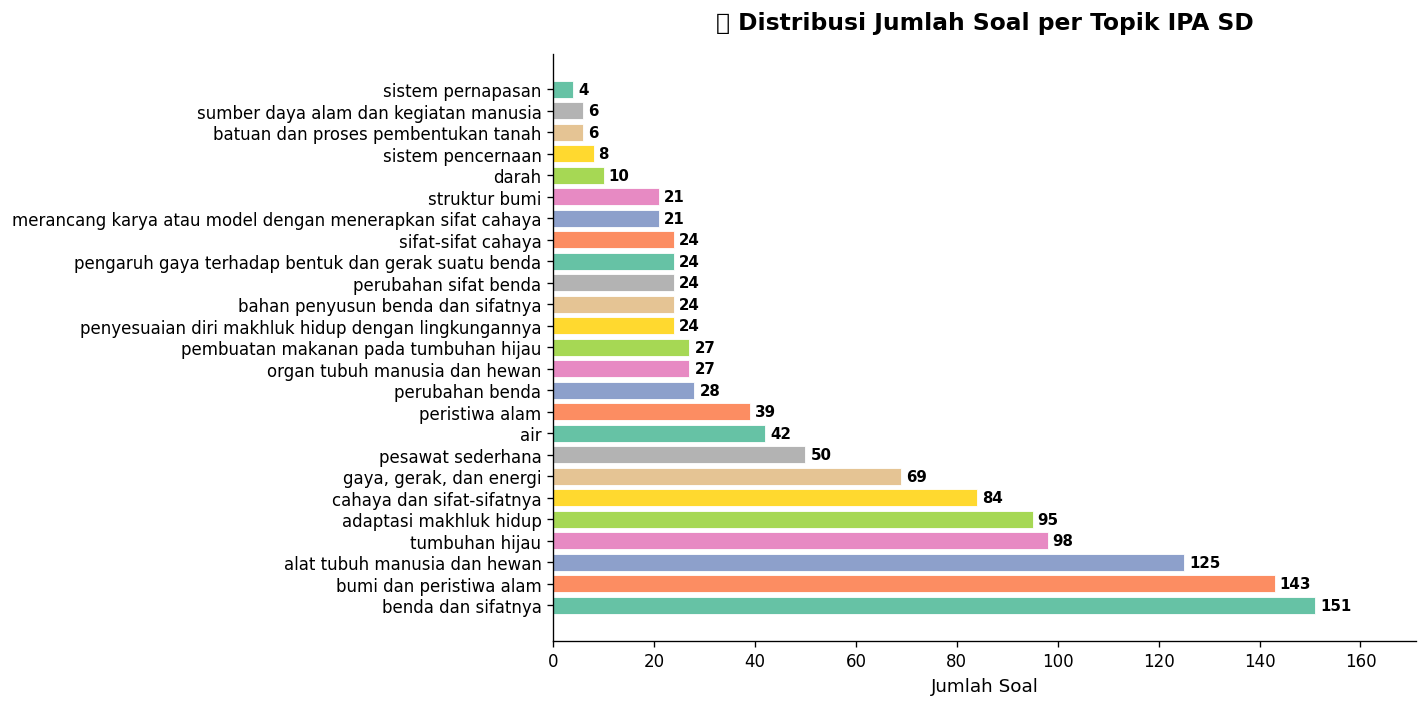

✅ Insight: Topik terbanyak adalah benda dan sifatnya (151 soal)


In [39]:
# --- VISUALISASI 1: Distribusi Jumlah Soal per Topik ---
fig, ax = plt.subplots(figsize=(12, 6))

topic_count = df['topik'].value_counts()
colors = sns.color_palette('Set2', len(topic_count))

bars = ax.barh(topic_count.index, topic_count.values, color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, topic_count.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', ha='left', fontsize=9, fontweight='bold')

ax.set_xlabel('Jumlah Soal', fontsize=11)
ax.set_title('📊 Distribusi Jumlah Soal per Topik IPA SD', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, topic_count.max() + 20)
plt.tight_layout()
plt.savefig('viz_01_distribusi_topik.png', bbox_inches='tight')
plt.show()
print('✅ Insight: Topik terbanyak adalah', topic_count.idxmax(), f'({topic_count.max()} soal)')

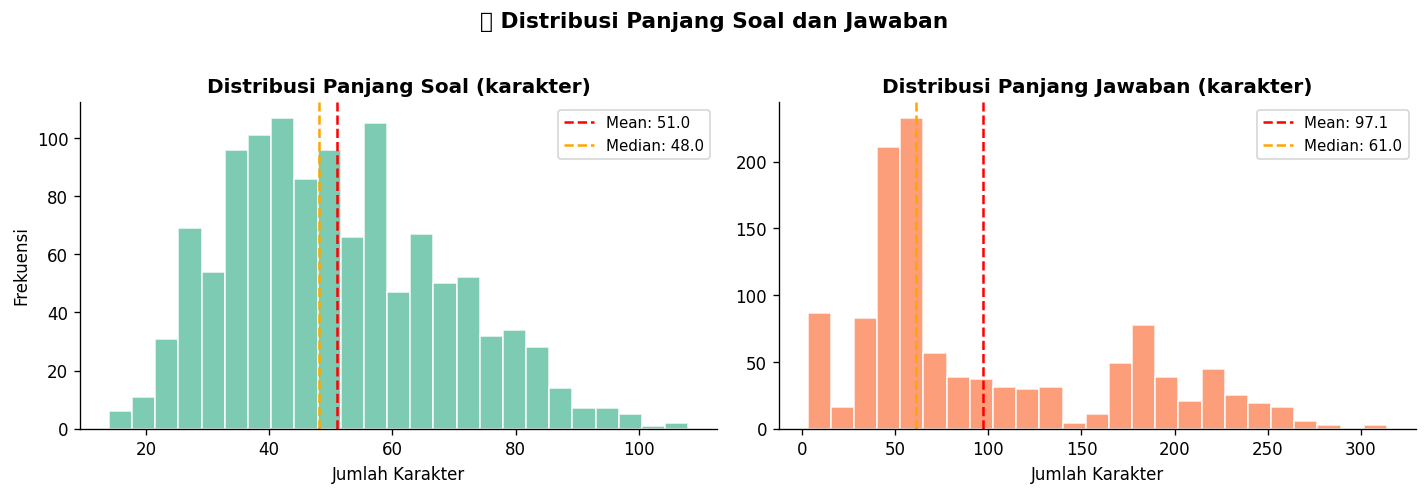

✅ Insight: Rata-rata soal memiliki 51 karakter; rata-rata jawaban 97 karakter


In [40]:
# --- VISUALISASI 2: Distribusi Panjang Soal & Jawaban ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram panjang soal
axes[0].hist(df['panjang_soal'], bins=25, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].axvline(df['panjang_soal'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {df["panjang_soal"].mean():.1f}')
axes[0].axvline(df['panjang_soal'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median: {df["panjang_soal"].median():.1f}')
axes[0].set_title('Distribusi Panjang Soal (karakter)', fontweight='bold')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].legend(fontsize=9)

# Histogram panjang jawaban
axes[1].hist(df['panjang_jawaban'], bins=25, color=PALETTE[1], edgecolor='white', alpha=0.85)
axes[1].axvline(df['panjang_jawaban'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {df["panjang_jawaban"].mean():.1f}')
axes[1].axvline(df['panjang_jawaban'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median: {df["panjang_jawaban"].median():.1f}')
axes[1].set_title('Distribusi Panjang Jawaban (karakter)', fontweight='bold')
axes[1].set_xlabel('Jumlah Karakter')
axes[1].legend(fontsize=9)

fig.suptitle('📏 Distribusi Panjang Soal dan Jawaban', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_02_distribusi_panjang.png', bbox_inches='tight')
plt.show()
print('✅ Insight: Rata-rata soal memiliki', round(df['panjang_soal'].mean()), 'karakter;',
      'rata-rata jawaban', round(df['panjang_jawaban'].mean()), 'karakter')

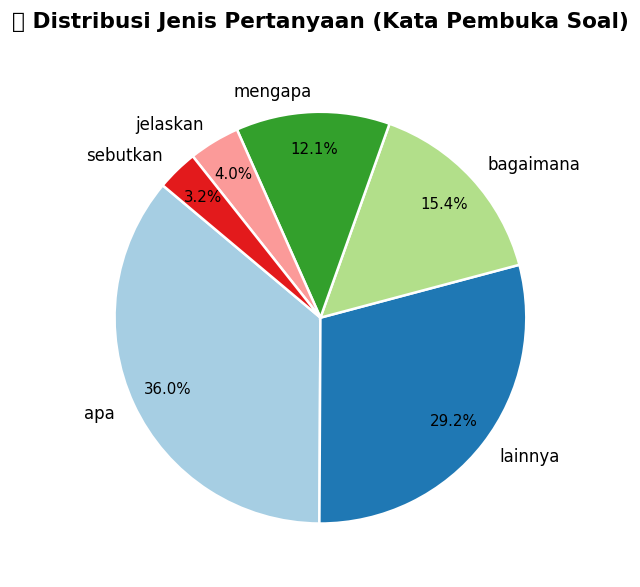

✅ Insight: Pertanyaan terbanyak dimulai dengan kata: apa


In [41]:
# --- VISUALISASI 3: Jenis Pertanyaan ---
fig, ax = plt.subplots(figsize=(8, 5))

jenis_count = df['jenis_pertanyaan'].value_counts()
colors = sns.color_palette('Paired', len(jenis_count))

wedges, texts, autotexts = ax.pie(
    jenis_count.values,
    labels=jenis_count.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.82,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

for at in autotexts:
    at.set_fontsize(9)

ax.set_title('🔤 Distribusi Jenis Pertanyaan (Kata Pembuka Soal)',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('viz_03_jenis_pertanyaan.png', bbox_inches='tight')
plt.show()
print('✅ Insight: Pertanyaan terbanyak dimulai dengan kata:', jenis_count.idxmax())

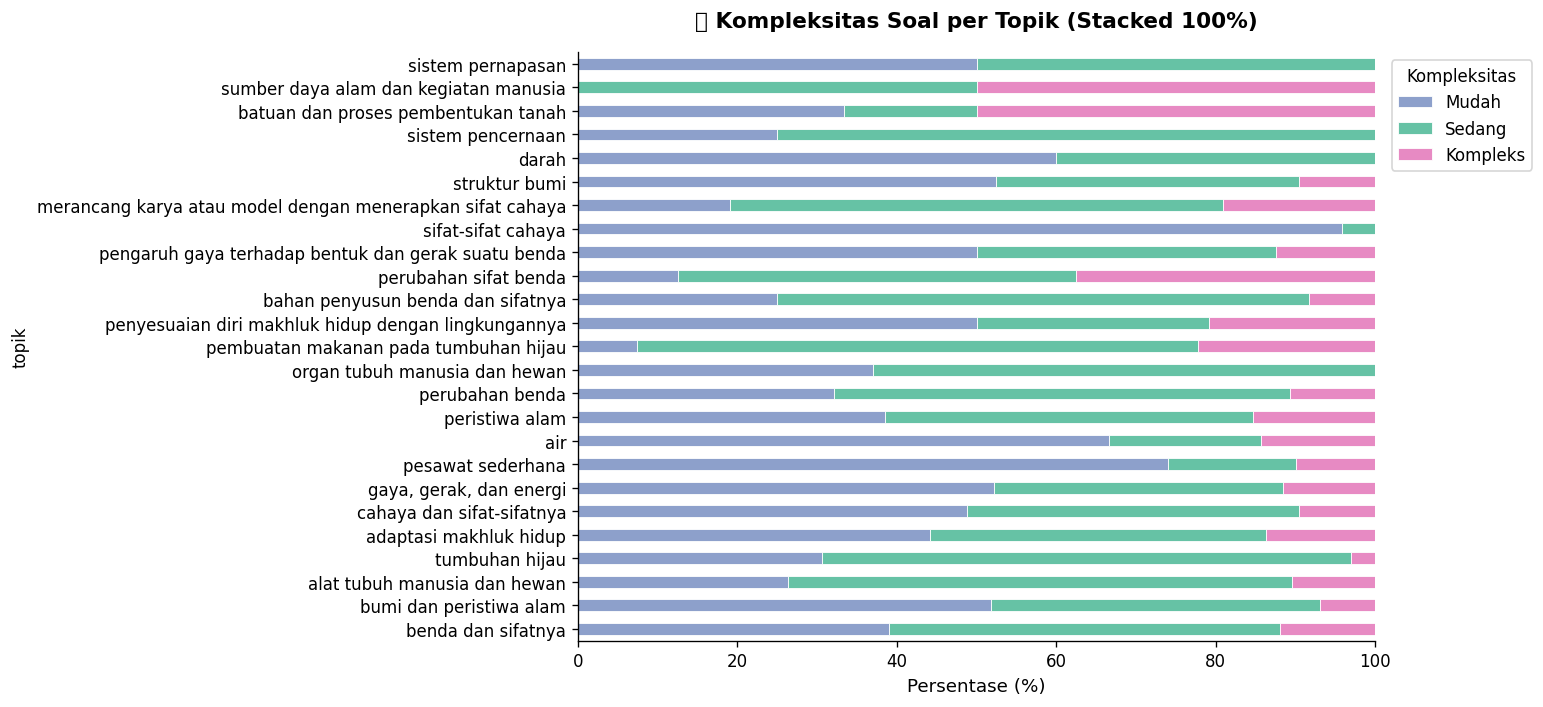

In [42]:
# --- VISUALISASI 4: Kompleksitas Soal per Topik ---
fig, ax = plt.subplots(figsize=(13, 6))

# Pivot table
pivot = df.groupby(['topik', 'kompleksitas']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=['Mudah', 'Sedang', 'Kompleks'], fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Sort by total
pivot_pct = pivot_pct.loc[df['topik'].value_counts().index]

pivot_pct.plot(kind='barh', stacked=True, ax=ax,
               color=[PALETTE[2], PALETTE[0], PALETTE[3]],
               edgecolor='white', linewidth=0.5)

ax.set_xlabel('Persentase (%)', fontsize=11)
ax.set_title('📊 Kompleksitas Soal per Topik (Stacked 100%)', fontsize=13, fontweight='bold', pad=15)
ax.legend(title='Kompleksitas', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig('viz_04_kompleksitas_topik.png', bbox_inches='tight')
plt.show()

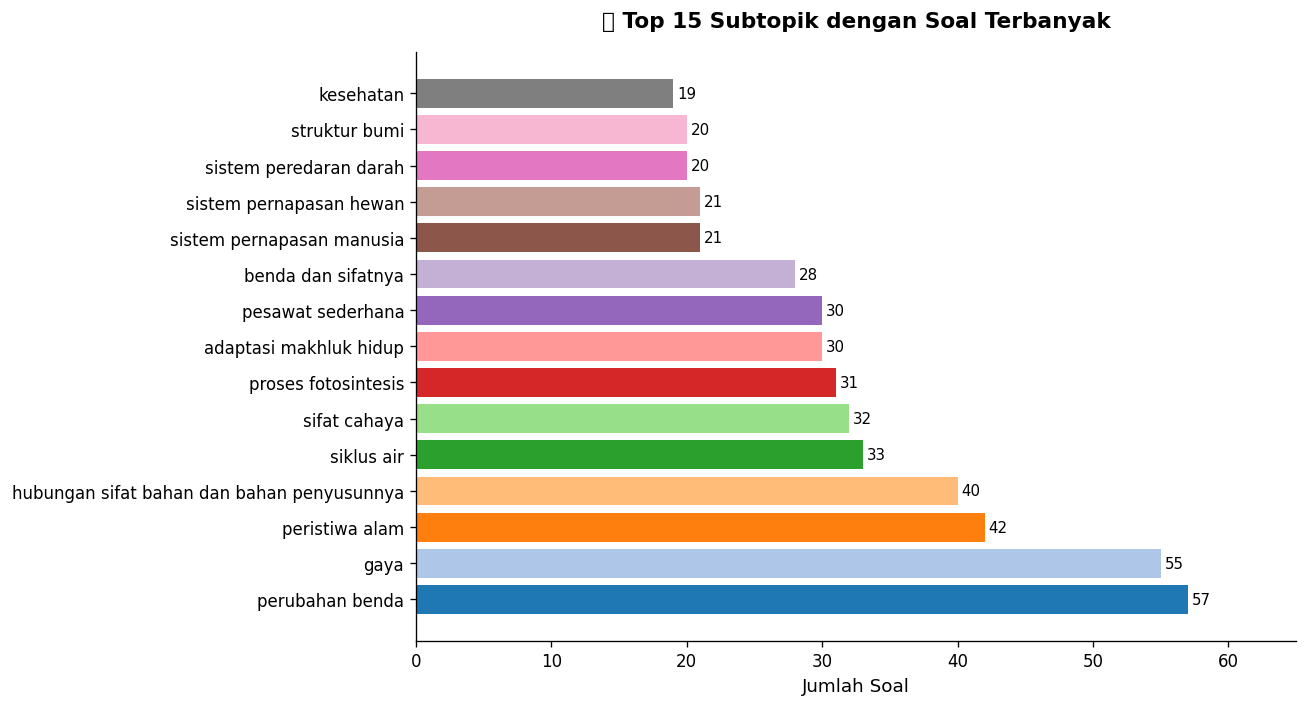

✅ Insight: Subtopik terbanyak adalah: perubahan benda (57 soal)


In [43]:
# --- VISUALISASI 5: Top 15 Subtopik ---
fig, ax = plt.subplots(figsize=(11, 6))

top15_subtopik = df['subtopik'].value_counts().head(15)
colors = sns.color_palette('tab20', 15)

bars = ax.barh(top15_subtopik.index, top15_subtopik.values, color=colors)
for bar, val in zip(bars, top15_subtopik.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', ha='left', fontsize=9)

ax.set_xlabel('Jumlah Soal', fontsize=11)
ax.set_title('🔎 Top 15 Subtopik dengan Soal Terbanyak', fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, top15_subtopik.max() + 8)
plt.tight_layout()
plt.savefig('viz_05_top_subtopik.png', bbox_inches='tight')
plt.show()
print('✅ Insight: Subtopik terbanyak adalah:', top15_subtopik.idxmax(),
      f'({top15_subtopik.max()} soal)')

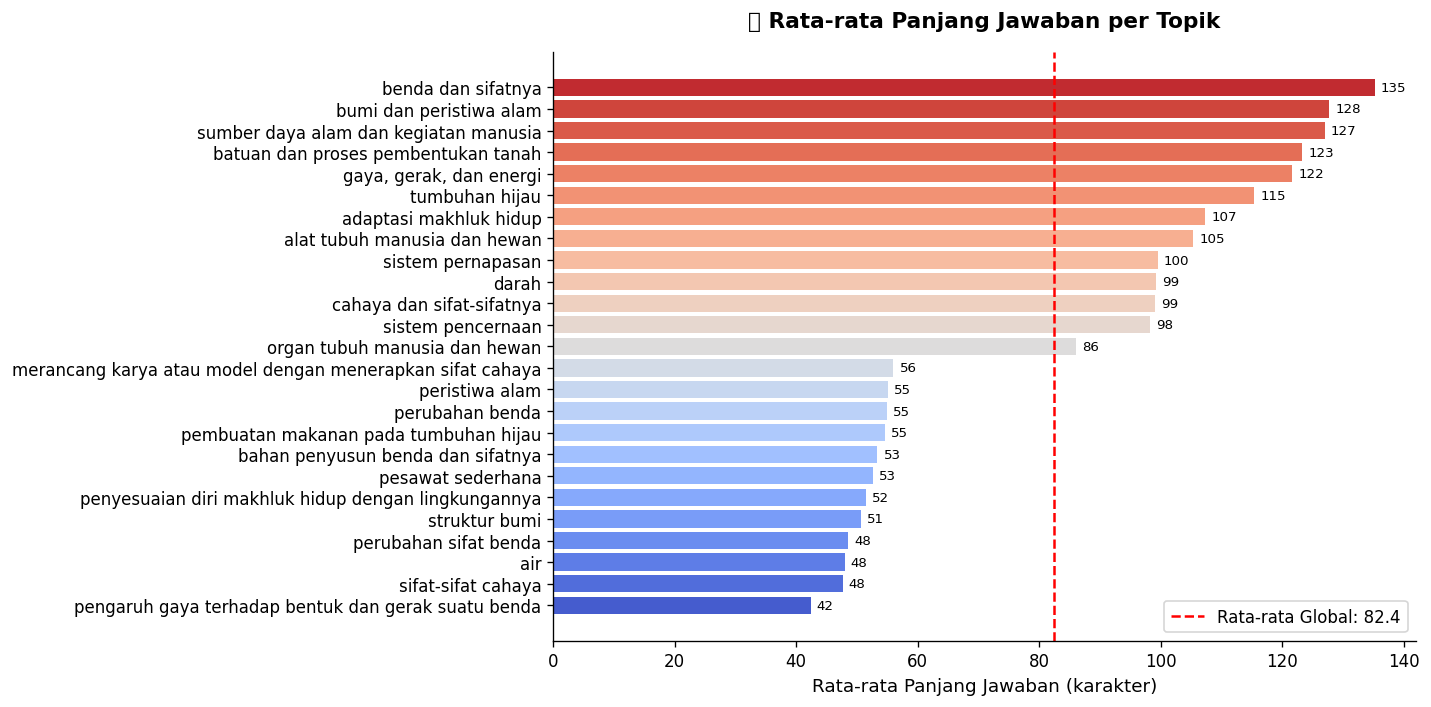

In [44]:
# --- VISUALISASI 6: Rata-rata Panjang Jawaban per Topik ---
fig, ax = plt.subplots(figsize=(12, 6))

avg_jawaban = df.groupby('topik')['panjang_jawaban'].mean().sort_values(ascending=True)
colors = sns.color_palette('coolwarm', len(avg_jawaban))

bars = ax.barh(avg_jawaban.index, avg_jawaban.values, color=colors)
ax.axvline(avg_jawaban.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Rata-rata Global: {avg_jawaban.mean():.1f}')

for bar, val in zip(bars, avg_jawaban.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', ha='left', fontsize=8)

ax.set_xlabel('Rata-rata Panjang Jawaban (karakter)', fontsize=11)
ax.set_title('📝 Rata-rata Panjang Jawaban per Topik', fontsize=13, fontweight='bold', pad=15)
ax.legend()
plt.tight_layout()
plt.savefig('viz_06_avg_jawaban_topik.png', bbox_inches='tight')
plt.show()

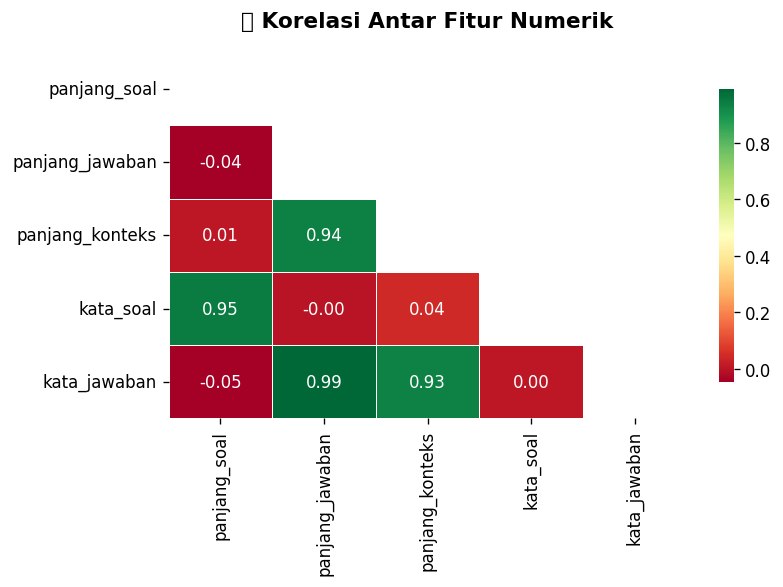

In [45]:
# --- VISUALISASI 7: Korelasi Fitur Numerik ---
fig, ax = plt.subplots(figsize=(7, 5))

num_cols = ['panjang_soal', 'panjang_jawaban', 'panjang_konteks',
            'kata_soal', 'kata_jawaban']
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})

ax.set_title('🔗 Korelasi Antar Fitur Numerik', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('viz_07_korelasi.png', bbox_inches='tight')
plt.show()

---
## 9️⃣ Data Dictionary

In [46]:
data_dict = {
    'Kolom': ['no', 'topik', 'subtopik', 'soal', 'jawaban', 'contoh', 'konteks',
              'link_sumber', 'panjang_soal', 'panjang_jawaban', 'panjang_konteks',
              'kata_soal', 'kata_jawaban', 'jenis_pertanyaan', 'kompleksitas'],
    'Tipe': ['int', 'str', 'str', 'str', 'str', 'str', 'str',
             'str', 'int', 'int', 'int', 'int', 'int', 'str', 'str'],
    'Deskripsi': [
        'Nomor urut soal (setelah reset)',
        'Topik utama IPA SD (sudah lowercase)',
        'Sub-topik yang lebih spesifik (sudah lowercase)',
        'Teks pertanyaan/soal',
        'Teks jawaban dari soal',
        'Contoh konkret untuk membantu pemahaman',
        'Kalimat latar belakang/konteks pertanyaan',
        'URL sumber buku ajar',
        'Jumlah karakter pada kolom soal',
        'Jumlah karakter pada kolom jawaban',
        'Jumlah karakter pada kolom konteks',
        'Jumlah kata pada kolom soal',
        'Jumlah kata pada kolom jawaban',
        'Jenis pertanyaan berdasarkan kata pembuka soal',
        'Tingkat kompleksitas soal berdasarkan jumlah kata'
    ],
    'Contoh Nilai': [
        '1, 2, 3', 'alat tubuh manusia dan hewan', 'sistem pernapasan manusia',
        'sebutkan alat pernapasan pada manusia!', 'rongga hidung berfungsi...',
        'udara masuk melalui hidung...', 'manusia bernapas dengan...',
        'https://...', '47', '125', '60', '6', '15', 'sebutkan', 'Mudah'
    ]
}

dd_df = pd.DataFrame(data_dict)
print('📖 DATA DICTIONARY')
dd_df

📖 DATA DICTIONARY


,Kolom,Tipe,Deskripsi,Contoh Nilai
0,no,int,Nomor urut soal (setelah reset),"1, 2, 3"
1,topik,str,Topik utama IPA SD (sudah lowercase),alat tubuh manusia dan hewan
2,subtopik,str,Sub-topik yang lebih spesifik (sudah lowercase),sistem pernapasan manusia
3,soal,str,Teks pertanyaan/soal,sebutkan alat pernapasan pada manusia!
4,jawaban,str,Teks jawaban dari soal,rongga hidung berfungsi...
5,contoh,str,Contoh konkret untuk membantu pemahaman,udara masuk melalui hidung...
6,konteks,str,Kalimat latar belakang/konteks pertanyaan,manusia bernapas dengan...
7,link_sumber,str,URL sumber buku ajar,https://...
8,panjang_soal,int,Jumlah karakter pada kolom soal,47
9,panjang_jawaban,int,Jumlah karakter pada kolom jawaban,125


---
## 🔟 Export Data Bersih

In [47]:
# Export clean dataset
EXPORT_PATH = '../data_cleran/datasoal_clean.csv'
df.to_csv(EXPORT_PATH, index=False)

print('✅ Data bersih berhasil disimpan!')
print(f'📁 Path  : {EXPORT_PATH}')
print(f'📊 Shape : {df.shape}')
print(f'📋 Kolom : {df.columns.tolist()}')

✅ Data bersih berhasil disimpan!
📁 Path  : ../data_cleran/datasoal_clean.csv
📊 Shape : (1174, 15)
📋 Kolom : ['no', 'topik', 'subtopik', 'soal', 'jawaban', 'contoh', 'konteks', 'link_sumber', 'panjang_soal', 'panjang_jawaban', 'panjang_konteks', 'kata_soal', 'kata_jawaban', 'jenis_pertanyaan', 'kompleksitas']


---
## 📌 Ringkasan Temuan (Summary of Insights)

| # | Insight | Detail |
|---|---------|--------|
| 1 | **Inkonsistensi Topik** | 29 nilai unik topik → 16 topik unik setelah normalisasi (duplikat kapitalisasi) |
| 2 | **Soal Duplikat** | Ditemukan 153 soal duplikat, dihapus untuk menjaga keunikan data |
| 3 | **Topik Terbanyak** | `alat tubuh manusia dan hewan` (131 soal) & `benda dan sifatnya` (gabungan ~200+) |
| 4 | **Panjang Soal** | Rata-rata 50 karakter (7–8 kata), distribusi normal |
| 5 | **Panjang Jawaban** | Rata-rata 99 karakter, distribusi right-skewed (ada jawaban sangat panjang) |
| 6 | **Jenis Pertanyaan** | Dominasi `sebutkan` dan `apa` — cocok untuk Q&A chatbot |
| 7 | **Kompleksitas** | Mayoritas soal tergolong `Sedang` (6–10 kata) |
| 8 | **Kesiapan Model** | Data siap digunakan sebagai input training NLP chatbot |

---
*Notebook selesai — Lanjutkan ke `dashboard.py` untuk visualisasi interaktif Streamlit.*

In [48]:
# Tambahan: simpan hasil clean ke data_cleran + opsi download
from pathlib import Path
import shutil

export_path = Path('../data_cleran/datasoal_clean.csv')
export_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(export_path, index=False)

backup_path = export_path.parent / 'datasoal_clean_backup.csv'
shutil.copy2(export_path, backup_path)

print('✅ File clean tersimpan di data_cleran')
print(f'📁 Path utama : {export_path}')
print(f'📁 Backup     : {backup_path}')

# Download file jika dijalankan di Google Colab
try:
    from google.colab import files
    files.download(str(export_path))
    print('⬇️ Download dimulai (Google Colab).')
except Exception:
    print('ℹ️ Lewati download otomatis (bukan Google Colab).')

✅ File clean tersimpan di data_cleran
📁 Path utama : ..\data_cleran\datasoal_clean.csv
📁 Backup     : ..\data_cleran\datasoal_clean_backup.csv
ℹ️ Lewati download otomatis (bukan Google Colab).
